**Install and import required libraries**

In [1]:
!pip install gdown scikit-image ipywidgets matplotlib

import gdown
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from ipywidgets import interact, FloatSlider
from IPython.display import display, Markdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.7 MB/s eta 0:00:00


**STEP 1: Download Image from Google Drive**

Downloading...
From: https://drive.google.com/uc?id=1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R
To: /content/chromaticity_image.jpg
100%|██████████| 92.6k/92.6k [00:00<00:00, 4.08MB/s]


**Image Loaded:** shape = (408, 612, 3)

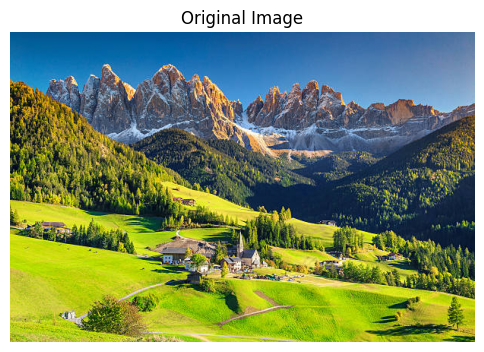

In [2]:
file_id = "1CPXI4SQSRRlq5HKJkW6_D5ezpxuN7B3R"  # From the given link
gdown.download(f"https://drive.google.com/uc?id={file_id}", "chromaticity_image.jpg", quiet=False)

# Load and normalize image
image = io.imread("chromaticity_image.jpg") / 255.0
h, w, _ = image.shape
display(Markdown(f"**Image Loaded:** shape = {image.shape}"))

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

**STEP 2: Convert to XYZ and Compute Chromaticity**

    Formula: x = X / (X+Y+Z), y = Y / (X+Y+Z)

In [3]:
xyz = color.rgb2xyz(image)
X, Y, Z = xyz[:,:,0], xyz[:,:,1], xyz[:,:,2]
denom = X + Y + Z + 1e-8
x_chroma = X / denom
y_chroma = Y / denom

# Downsample for plotting chromaticity diagram (avoid too many points)
sample_rate = 20
x_chroma_sample = x_chroma[::sample_rate, ::sample_rate].flatten()
y_chroma_sample = y_chroma[::sample_rate, ::sample_rate].flatten()

**Plot Chromaticity Diagram (Original Image)**

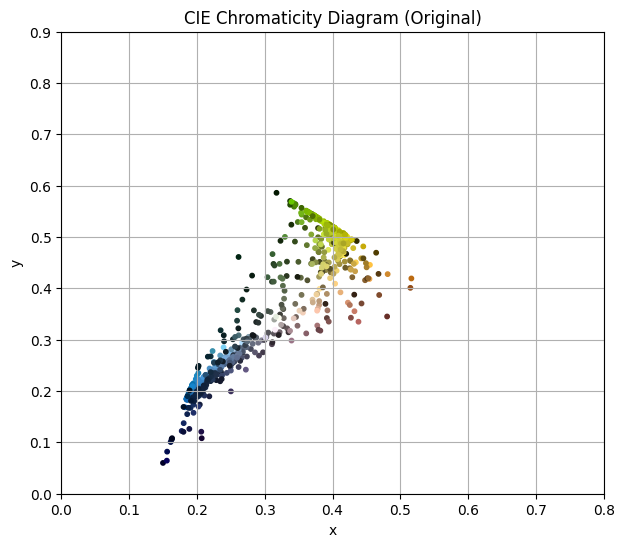


### **Chromaticity Coordinates**
- Defined as:
  \( x = \frac{X}{X+Y+Z}, \; y = \frac{Y}{X+Y+Z} \)
- Represents color independent of intensity (brightness).


In [4]:
plt.figure(figsize=(7,6))
plt.scatter(x_chroma_sample, y_chroma_sample, s=10, c=image[::sample_rate, ::sample_rate].reshape(-1,3))
plt.title("CIE Chromaticity Diagram (Original)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, 0.8)
plt.ylim(0, 0.9)
plt.grid(True)
plt.show()

display(Markdown("""
### **Chromaticity Coordinates**
- Defined as:
  \\( x = \\frac{X}{X+Y+Z}, \\; y = \\frac{Y}{X+Y+Z} \\)
- Represents color independent of intensity (brightness).
"""))

**STEP 3: Interactive Saturation Control**

In [5]:
display(Markdown("""
### **Saturation Adjustment Formula**
\\[
I' = (1 - s) I_{gray} + s I_{original}
\\]
- If \\( s < 1 \\): Desaturation
- If \\( s = 1 \\): Original
- If \\( s > 1 \\): Oversaturation
"""))

gray = color.rgb2gray(image)
gray_rgb = np.stack([gray, gray, gray], axis=-1)

def adjust_saturation(s=1.0):
    # Apply saturation adjustment
    modified = (1-s)*gray_rgb + s*image
    modified = np.clip(modified, 0, 1)

    # Compute chromaticity for modified image
    xyz_mod = color.rgb2xyz(modified)
    X_m, Y_m, Z_m = xyz_mod[:,:,0], xyz_mod[:,:,1], xyz_mod[:,:,2]
    denom_m = X_m + Y_m + Z_m + 1e-8
    x_mod = X_m / denom_m
    y_mod = Y_m / denom_m

    # Downsample for plotting
    x_mod_sample = x_mod[::sample_rate, ::sample_rate].flatten()
    y_mod_sample = y_mod[::sample_rate, ::sample_rate].flatten()

    # Plot results
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(modified)
    axes[0].set_title(f"Image (Saturation: {s:.2f})")
    axes[0].axis('off')

    axes[1].scatter(x_mod_sample, y_mod_sample, s=10, c=modified[::sample_rate, ::sample_rate].reshape(-1,3))
    axes[1].set_title("CIE Chromaticity Diagram (Modified)")
    axes[1].set_xlim(0, 0.8)
    axes[1].set_ylim(0, 0.9)
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].grid(True)

    plt.show()

# Interactive slider for saturation control
interact(adjust_saturation, s=FloatSlider(min=0, max=2, step=0.1, value=1.0, description="Saturation"))


### **Saturation Adjustment Formula**
\[
I' = (1 - s) I_{gray} + s I_{original}
\]
- If \( s < 1 \): Desaturation
- If \( s = 1 \): Original
- If \( s > 1 \): Oversaturation


interactive(children=(FloatSlider(value=1.0, description='Saturation', max=2.0), Output()), _dom_classes=('wid…

<function __main__.adjust_saturation(s=1.0)>

**Summary**

    This notebook demonstrates chromaticity coordinates (x,y) and
    allows interactive saturation/desaturation adjustments on an image.

    It also plots the chromaticity diagram for original and modified images.